#  Hyperparameter Tuning & GridSearchCV
Welcome, This course covers the fundamentals of hyperparameter tuning, the mechanics of Cross-Validation, and practical implementation using `scikit-learn`'s `GridSearchCV`.

## Module 1: Introduction to Hyperparameters
* **1.1 Parameters vs. Hyperparameters:** Understanding the difference between model-learned parameters (e.g., weights in linear regression) and user-defined hyperparameters (e.g., learning rate, tree depth).
* **1.2 The Need for Tuning:** How hyperparameters affect model performance (Underfitting vs. Overfitting).
* **1.3 The Curse of Dimensionality in Tuning:** Why exhaustive search becomes computationally expensive.

# The Core Definition

## Model Parameters
These are the internal variables that the model **learns automatically** from the training data.  
The data scientist does **not** set these manually.  

They are the **output of the learning process**.

Examples:
- Weights in Linear Regression
- Coefficients in Logistic Regression
- Weights and biases in Neural Networks
- Split thresholds in Decision Trees


---

## Hyperparameters
These are the **external configuration settings** that the data scientist sets **before the training process begins**.  

They guide **how the model learns**.

Examples:
- Learning rate
- Number of trees in Random Forest
- Maximum depth of a tree
- Number of hidden layers in a Neural Network
- Regularization strength (λ)


---

## Key Difference

| Model Parameters | Hyperparameters |
|------------------|------------------|
| Learned automatically | Set manually before training |
| Internal to the model | External configuration |
| Output of training | Input to training |
| Example: weights | Example: learning rate |

### Hyperparameters Control

They control:

- 🧠 **Model complexity**
- ⚡ **Training speed**
- 🎯 **Accuracy**
- 🚫 **Overfitting**

# Examples: Parameters vs Hyperparameters

---

## 1️⃣ Linear Regression

### Parameters:
- The weights ($w_1, w_2, \dots, w_n$)
- The bias ($b$)

The model calculates these automatically during training  
(e.g., using **Ordinary Least Squares**).

### Hyperparameters:
- If using Gradient Descent → the **Learning Rate ($\alpha$)**  

You must set this **before training begins**.

---

## 2️⃣ Decision Trees

### Parameters:
- The actual decision rules at each node  
  (e.g., *"Is Age > 25?"*, *"Is Income < $50k?"*)

The model determines these splits based on the data.

### Hyperparameters:
- **Maximum Depth (`max_depth`)**

You decide beforehand how deep the tree can grow  
(e.g., maximum 5 levels).

---


# 1.2 The Need for Tuning: Underfitting vs Overfitting

## 🎯 The Goal

Why do we care about hyperparameters?

Because they control **how complex a model is**.

If the model is:
- Too simple → **Underfitting**
- Too complex → **Overfitting**
- Just right → **Good Fit**

Tuning helps us find the **best balance**.

---





## 💡 Easy Analogy: Student Studying for an Exam

### 📉 Underfitting (Too Simple)
A student only reads the chapter titles and goes to sleep.  
They fail because they didn't study enough.

👉 The model didn’t learn enough patterns.

---

### 📈 Overfitting (Too Complex)
A student memorizes answers from one practice test word-for-word.  
In the real exam, numbers change slightly — they fail.

👉 The model memorized training data instead of understanding patterns.

---

### ✅ Good Fit (Tuned Properly)
A student understands the formulas and concepts.  
They can solve new problems easily.

👉 The model learns general patterns that work on new data.

---

## 🛠️ Example: `max_depth` in a Decision Tree

### 🌳 max_depth = 1
- Very small tree
- Too simple
- Result → **Underfitting**

---

### 🌳 max_depth = None
- Tree grows until it memorizes everything
- Perfect on training data
- Poor on new data
- Result → **Overfitting**

---

### 🌳 max_depth = 5
- Balanced complexity
- Captures important patterns
- Ignores random noise
- Result → **Good Fit**

---



![Underfitting vs Good Fit vs Overfitting](figure.jpg)

# Understanding Underfitting, Good Fit, and Overfitting

---

## 📉 Left Side – Underfitting (bad on both training and testing)

- **Model is too simple**
- **High bias**
- **Poor performance** on training and testing data
- **Example:** Linear model trying to fit complex data


---

## ✅ Middle – Good Fit (Optimal Model)

- **Balanced bias and variance**
- **Learns patterns properly**
- **Performs well** on unseen data
- **Best generalization**

💡 *This is the goal of training.*

---

## 📈 Right Side – Overfitting  (great on training, bad on testing)

- **Model is too complex**
- **Memorizes training data**
- **High variance**
- **Poor performance** on new data
- **Example:** Deep neural network on small dataset


---



# 1.3 The Curse of Dimensionality in Hyperparameter Tuning

---

## 🎯 The Goal
To understand **why we can't just try every possible hyperparameter** and why tuning can take a lot of time.

---

## 📖 The Core Concept
**The Curse of Dimensionality** means:  
> As you add more hyperparameters to tune, the number of combinations grows **exponentially**.  

Checking every combination (brute force) **quickly becomes impossible**.

---

## 💡 Analogy: The Combination Padlock
- **1 dial (0-9):** 10 tries max  
- **3 dials:** 10 × 10 × 10 = 1,000 tries  
- **5 dials:** 10 × 10 × 10 × 10 × 10 = 100,000 tries  

> Every new dial (hyperparameter) **multiplies the work**.

---

## 🛠️ Mathematical Example

Suppose we tune a **Random Forest Classifier** with these options:

| Hyperparameter | Options |
|----------------|---------|
| n_estimators | 10, 50, 100, 200, 500 (5 options) |
| max_depth | None, 10, 20, 30 (4 options) |
| min_samples_split | 2, 5, 10, 15, 20 (5 options) |


**Total combinations:**  

5 × 4 × 5  = 100 unique models


Using **5-Fold Cross-Validation**:  


100 combinations × 5 folds = 500 model trainings



If **1 model takes 1 minute**, the total time = **8.33 hours**!  
Add one more hyperparameter with 10 options → **83.3 hours (~3, 4 days)**!

---

# Module 2: Cross-Validation (The Foundation)

---

## **2.1 What is Cross-Validation?**  
Cross-validation is a technique to **evaluate how well your model will perform on unseen data**.  

- The simple **train-test split** divides your dataset once into a training set and a test set.  
- Problem: The model’s performance depends heavily on **which data ends up in the training vs test set**.  
- **Cross-validation** solves this by **splitting the data multiple times** and averaging results for a more reliable estimate.  

💡 *Analogy:* Testing a recipe multiple times on different groups of friends instead of relying on just one tasting session.  

---

## **2.2 K-Fold Cross-Validation**  
K-Fold Cross-Validation splits the dataset into **K equal parts (folds)**:

1. Use **K-1 folds** to train the model.  
2. Use the **remaining fold** to test the model.  
3. Repeat this process **K times**, each time using a different fold as the test set.  
4. Average the performance across all K runs → **robust estimate of model performance**.  

- Common choice: **K = 5 or 10**  
- Pros: More reliable than a single train-test split, especially on small datasets  

💡 *Example:* With 5-Fold CV, each fold is tested once → 5 performance scores → take the average.  

---

## **2.3 Stratified K-Fold**  
- Sometimes datasets are **imbalanced** (e.g., 90% class A, 10% class B).  
- Regular K-Fold may split data unevenly → some folds might have very few minority class samples.  
- **Stratified K-Fold** ensures **each fold preserves the class proportion** of the original dataset.  

💡 *Analogy:* Think of making sure each tasting group gets a **balanced mix of cookie types** instead of ending up with only chocolate chip cookies in one group.  

- In scikit-learn:

```python
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5)
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

# Module 3: Introduction to GridSearchCV 

---

## **3.1 The Grid Search Concept**

**The Goal:**  
 We are **systematically defining a finite set of values** to test.

---

### 📖 Core Concept
Grid Search is an **exhaustive search algorithm**:

- You provide a list of hyperparameters and specific values to test.  
- It builds a **mathematical grid** of all possible combinations.  
- Each combination is evaluated to find the **best hyperparameters**.

---

### 💡 Analogy: Restaurant Combo Meal
Imagine building a combo meal:

| Choice | Options | Number of options |
|--------|--------|-----------------|
| Main   | Burger, Chicken Sandwich, Veggie Wrap | 3 |
| Side   | Fries, Salad | 2 |
| Drink  | Soda, Water | 2 |

- Total meals to try = 3 × 2 × 2 = **12 meals**  
- A **Grid Search** is like trying **every possible combo** to find the best one.

---

### 🛠️ Technical Example (Random Forest)

```python
param_grid = {
    'n_estimators': [10, 50],       # 2 options
    'max_depth': [5, 10, None],     # 3 options
}

## 3.2 How GridSearchCV Works (Grid Search + K-Fold CV)

**The Goal:**  
Must understand that **each combination is evaluated rigorously using Cross-Validation**.

---

### 📖 Core Concept
**GridSearchCV = Grid Search + Cross-Validation**  

- For **each hyperparameter combination**, it runs a **full K-Fold Cross-Validation**.  
- The **best parameters** are the ones with the **highest average score** across all folds.

---

### 💡 Analogy: Taste Test Panel
- One person tasting all meals → **biased opinion**.  
- 5 judges tasting all meals → **average score is fairer**.  
- Similarly, **5-Fold CV evaluates each combination on multiple folds** to ensure reliability.

---

### 🛠️ Step-by-Step
1. Pick **combination #1** from the grid.  
2. Split the training data into **K folds**.  
3. Train on **K-1 folds**, test on the remaining fold.  
4. Repeat **K times** → calculate **average score** for combination #1.  
5. Repeat steps 1–4 for **all combinations**.  
6. Compare all averages → pick the **best combination**.

---



                    START
                      │
                      ▼
            ┌─────────────────┐
            │   Define your   │
            │   model &       │
            │   parameters    │
            └─────────────────┘
                      │
                      ▼
            ┌─────────────────┐
            │ Create a GRID   │
            │ of all possible │
            │ combinations    │
            └─────────────────┘
                      │
                      ▼
            ┌──────────────────────────────────┐
            │                                  │
    ┌───────┴───────┐                 ┌────────┴────────┐
    │ Combination 1 │                 │ Combination 2   │
    │ n_estimators=10│                 │ n_estimators=10 │
    │ max_depth=3   │                 │ max_depth=5     │
    └───────┬───────┘                 └────────┬────────┘
            │                                  │
            ▼                                  ▼
    ┌───────────────┐                  ┌───────────────┐
    │ CROSS-VALIDATE│                  │ CROSS-VALIDATE│
    │               │                  │               │
    │ Fold 1: 85%   │                  │ Fold 1: 86%   │
    │ Fold 2: 84%   │                  │ Fold 2: 87%   │
    │ Fold 3: 86%   │                  │ Fold 3: 88%   │
    │ ────────      │                  │ ────────      │
    │ AVG: 85%      │                  │ AVG: 87%      │
    └───────┬───────┘                  └───────┬───────┘
            │                                  │
            └──────────────┬───────────────────┘
                           │
                           ▼
            ┌──────────────────────────────────┐
            │      Compare ALL results         │
            │                                  │
            │  Combo 1: 85%  │  Combo 5: 89%   │
            │  Combo 2: 87%  │  Combo 6: 91%   │
            │  Combo 3: 86%  │  Combo 7: 90%   │
            │  Combo 4: 88%  │  Combo 8: 88%   │
            └──────────────────────────────────┘
                           │
                           ▼
            ┌──────────────────────────────────┐
            │      🏆 PICK THE BEST!           │
            │   Best combo: Combo 6 (91%)      │
            │   Best params:                   │
            │   n_estimators=50, max_depth=5   │
            └──────────────────────────────────┘
                           │
                           ▼
                         FINISH

# 📊 Manual Calculation of ROC-AUC

You are given:


actual = [0, 0, 1, 1, 1, 0, 0]

predicted = [0.1, 0.3, 0.4, 0.9, 0.76, 0.55, 0.2]


---

## 🎯 Step 1: Understand What AUC Means

**AUC (Area Under the Curve)** is:

> The probability that a randomly chosen positive example has a higher predicted score than a randomly chosen negative example.

Instead of constructing the ROC curve using thresholds, we compute AUC using **pairwise comparison**.

---

## 🔢 Step 2: Separate Positives and Negatives

### ✅ Positives (actual = 1)

Scores:


0.4, 0.9, 0.76


Total positives = **3**

---

### ❌ Negatives (actual = 0)

Scores:


0.1, 0.3, 0.55, 0.2


Total negatives = **4**

---

## 🔁 Step 3: Compare Every Positive vs Every Negative

Total comparisons:

$$
3 \times 4 = 12
$$

Now check whether:

$$
\text{positive score} > \text{negative score}
$$

---

### 🔹 Positive = 0.4

- 0.1 ✅  
- 0.3 ✅  
- 0.55 ❌  
- 0.2 ✅  

Wins = **3**

---

### 🔹 Positive = 0.9

- 0.1 ✅  
- 0.3 ✅  
- 0.55 ✅  
- 0.2 ✅  

Wins = **4**

---

### 🔹 Positive = 0.76

- 0.1 ✅  
- 0.3 ✅  
- 0.55 ✅  
- 0.2 ✅  

Wins = **4**

---

## 🧮 Step 4: Compute AUC

Total wins:

$$
3 + 4 + 4 = 11
$$

Total comparisons:

$$
12
$$

$$
\text{AUC} = \frac{11}{12} = 0.9167
$$

---

## ✅ Final Answer

$$
\boxed{\text{ROC-AUC} \approx 0.917}
$$

---

## 🧠 Interpretation

There is a **91.7\% probability** that a randomly chosen positive example has a higher predicted probability than a randomly chosen negative example.

This indicates a **strong classifier**.

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import roc_auc_score


In [3]:
import matplotlib.pyplot as plt

In [4]:
#Recursive Feature Elimination with Cross-Validation

In [5]:
# Load dataset
digits = load_digits()

In [6]:
digits.data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [7]:
digits.target

array([0, 1, 2, ..., 8, 9, 8], shape=(1797,))

In [18]:
digits.data.shape

(1797, 64)

In [19]:
digits.target

array([0, 1, 2, ..., 8, 9, 8], shape=(1797,))

In [9]:
type(digits)

sklearn.utils._bunch.Bunch

In [12]:
X = digits.data

In [16]:
X[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [11]:
print(digits.keys())


dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


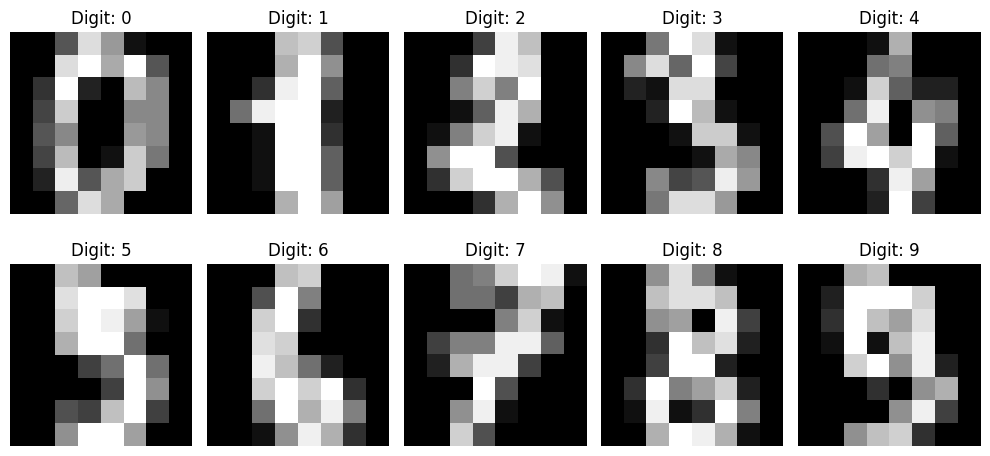

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(f"Digit: {digits.target[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [20]:
X, y = digits.data, digits.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy']
}

# Initialize RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,              # 5-Fold Cross Validation
    n_jobs=-1,         # Use all CPU cores
    verbose=0  # Prints progress
)

# Fit the Grid Search to your training data
grid_search.fit(X_train, y_train)

# Best combination found
print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

Best Hyperparameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation Score: 0.9725292578824177


In [25]:
# Predict on the test set
y_pred = grid_search.predict(X_test)
y_pred_proba = grid_search.predict_proba(X_test)

# Evaluate the model
roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print("ROC AUC Score on test data: ", roc_auc)

ROC AUC Score on test data:  0.9991594574597912


In [35]:
pd.Series(y_pred).unique()

array([1, 0, 9, 5, 6, 7, 2, 4, 8, 3])

In [26]:
print(len(X_test))

450


In [19]:
X_test[1]

array([ 0.,  0.,  4., 12.,  5.,  0.,  0.,  0.,  0.,  0., 12., 14., 15.,
        7.,  0.,  0.,  0.,  2., 14.,  1.,  2., 16.,  0.,  0.,  0.,  4.,
        8.,  0.,  0., 10.,  4.,  0.,  0.,  7.,  8.,  0.,  0.,  6.,  8.,
        0.,  0.,  4., 11.,  0.,  0.,  5.,  8.,  0.,  0.,  0., 14., 11.,
        3., 13.,  5.,  0.,  0.,  0.,  2., 11., 16., 11.,  0.,  0.])

In [ ]:
arr = [
    0., 0., 4., 12., 5., 0., 0., 0.,
    0., 0., 12., 14., 15., 7., 0., 0.,
    0., 2., 14., 1., 2., 16., 0., 0.,
    0., 4., 8., 0., 0., 10., 4., 0.,
    0., 7., 8., 0., 0., 6., 8., 0.,
    0., 4., 11., 0., 0., 5., 8., 0.,
    0., 0., 14., 11., 3., 13., 5., 0.,
    0., 0., 2., 11., 16., 11., 0., 0.
]

In [23]:
y_test[6]

7

In [36]:
print(y_pred)

[1 0 9 1 5 6 7 9 1 5 5 9 2 2 7 6 5 4 8 6 9 4 0 6 0 1 2 0 4 7 3 3 8 7 4 6 5
 1 5 5 4 0 8 8 5 8 4 3 0 7 2 5 1 2 1 1 4 4 9 5 2 5 4 9 0 2 4 1 7 9 6 1 8 5
 4 3 4 4 3 6 1 0 1 2 3 7 7 2 9 6 5 8 2 6 7 5 9 7 0 5 0 1 1 9 2 4 6 5 1 0 0
 9 7 8 4 2 8 4 1 4 0 4 7 5 7 1 3 9 2 7 2 6 9 7 0 0 1 6 3 5 1 6 0 9 6 7 4 1
 6 6 7 5 8 8 3 4 4 9 0 2 9 0 9 6 0 7 6 4 4 6 7 7 4 6 9 7 4 3 5 2 0 8 4 5 8
 3 5 7 8 3 9 8 6 2 8 4 2 1 9 3 8 9 2 5 1 0 9 3 0 4 4 5 5 3 3 6 3 1 0 6 7 1
 6 9 6 3 2 3 0 7 7 1 5 5 9 3 4 2 8 3 7 3 9 5 2 2 3 5 6 0 4 2 2 8 8 1 3 0 9
 6 8 0 3 3 1 1 4 8 8 9 1 7 6 2 1 0 2 3 9 7 7 7 9 2 5 9 5 7 3 5 9 7 1 8 0 4
 2 3 1 7 2 8 3 6 3 1 4 1 4 0 1 6 3 2 7 6 3 1 1 0 1 8 3 3 4 6 4 0 2 1 2 8 2
 9 6 6 6 4 9 1 1 1 8 6 7 5 8 1 8 6 7 3 2 0 2 3 8 5 0 9 4 2 1 4 5 7 9 4 2 6
 5 9 3 5 8 4 2 1 5 9 1 9 3 7 3 7 7 3 3 4 3 7 3 7 3 0 5 2 9 6 5 5 2 1 7 0 2
 3 0 0 1 2 7 8 3 5 9 8 0 9 4 1 6 6 9 0 0 6 0 7 5 5 8 6 8 2 7 4 9 5 7 6 1 7
 8 8 0 3 4 8]


In [ ]:
y_pred_proba[36]

In [37]:
for i, j in zip(y_test, y_pred):
    print(i,j)

1 1
0 0
9 9
1 1
5 5
6 6
7 7
9 9
1 1
5 5
5 5
9 9
2 2
2 2
7 7
6 6
5 5
4 4
8 8
6 6
9 9
4 4
0 0
6 6
0 0
8 1
2 2
0 0
4 4
7 7
3 3
3 3
8 8
7 7
4 4
6 6
5 5
1 1
5 5
5 5
4 4
0 0
8 8
8 8
5 5
8 8
4 4
3 3
0 0
7 7
2 2
5 5
1 1
2 2
1 1
1 1
4 4
4 4
9 9
5 5
2 2
5 5
0 4
9 9
0 0
2 2
4 4
1 1
7 7
9 9
6 6
1 1
8 8
5 5
4 4
3 3
4 4
4 4
3 3
6 6
1 1
0 0
1 1
2 2
3 3
7 7
7 7
2 2
9 9
6 6
5 5
8 8
2 2
6 6
7 7
5 5
9 9
7 7
0 0
5 5
0 0
1 1
1 1
9 9
2 2
4 4
6 6
5 5
1 1
0 0
0 0
9 9
8 7
8 8
4 4
2 2
8 8
4 4
1 1
4 4
0 0
0 4
7 7
5 5
7 7
1 1
3 3
9 9
2 2
7 7
2 2
6 6
9 9
7 7
0 0
0 0
1 1
6 6
3 3
5 5
1 1
6 6
0 0
9 9
6 6
7 7
4 4
1 1
6 6
6 6
7 7
5 5
8 8
8 8
3 3
4 4
4 4
9 9
0 0
2 2
9 9
0 0
9 9
6 6
0 0
7 7
6 6
4 4
4 4
6 6
7 7
7 7
4 4
6 6
9 9
7 7
4 4
3 3
5 5
2 2
0 0
8 8
4 4
5 5
8 8
3 3
5 5
7 7
8 8
3 3
9 9
8 8
6 6
2 2
9 8
4 4
2 2
1 1
9 9
9 3
6 8
9 9
2 2
5 5
1 1
0 0
9 9
3 3
0 0
4 4
4 4
5 5
5 5
3 3
3 3
6 6
3 3
1 1
0 0
6 6
7 7
1 1
6 6
9 9
6 6
3 3
2 2
3 3
0 0
7 7
8 7
1 1
5 5
5 5
9 9
3 3
4 4
2 2
8 8
8 3
9 7
3 3
5 9
5 5
2 2
2 2
3 3
5 5
6 6
0 0


In [ ]:
from tempfile import mkdtemp
from shutil import rmtree
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
estimators = [('reduce_dim', PCA()), ('clf', SVC())]
cachedir = mkdtemp()
pipe = Pipeline(estimators, memory=cachedir)
pipe
# Clear the cache directory when you don't need it anymore


In [ ]:
# Define the classifier
clf = RandomForestClassifier(random_state=42, class_weight="balanced")

# Define the feature selector
rfecv = RFECV(estimator=clf, step=1, cv=StratifiedKFold(10), scoring='roc_auc')

# Create a pipeline
pipeline = Pipeline([
    ('feature_selection', rfecv),
    ('classification', clf)
])

In [ ]:
pipeline.fit(X, y)

In [9]:
# Module 3: Using GridSearchCV with Breast Cancer Dataset

import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

data = load_breast_cancer()
X = data.data
y = data.target

In [13]:
X.shape

(569, 30)

In [14]:
y.shape

(569,)

In [ ]:
data.shape

In [ ]:
data.shape


In [10]:
#  Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#  Define the Random Forest model
rf = RandomForestClassifier(random_state=42)

# Set up hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

In [11]:
# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,               # 5-fold cross-validation
    scoring='accuracy', # metric to optimize
    n_jobs=-1           # use all cores
)

#  Fit GridSearchCV to training data
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True, False], 'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",T

In [15]:
#  Best parameters and score
print("Best Hyperparameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

#  Evaluate on test set
y_pred = grid_search.predict(X_test)
print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Best Hyperparameters: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy: 0.964835164835165

Test Accuracy: 0.956140350877193

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [16]:
data.data[0]

array([1.799e+01, 1.038e+01, 1.228e+02, 1.001e+03, 1.184e-01, 2.776e-01,
       3.001e-01, 1.471e-01, 2.419e-01, 7.871e-02, 1.095e+00, 9.053e-01,
       8.589e+00, 1.534e+02, 6.399e-03, 4.904e-02, 5.373e-02, 1.587e-02,
       3.003e-02, 6.193e-03, 2.538e+01, 1.733e+01, 1.846e+02, 2.019e+03,
       1.622e-01, 6.656e-01, 7.119e-01, 2.654e-01, 4.601e-01, 1.189e-01])

In [ ]:
X

In [17]:
new_patient1 = np.array([
    [14.0, 20.0, 90.0, 600.0, 0.1, 0.2, 1.0, 15.0, 0.02, 0.03,
     0.3, 1.0, 2.0, 30.0, 0.006, 0.02, 0.03, 0.015, 0.02, 0.003,
     16.0, 25.0, 105.0, 700.0, 0.14, 0.35, 1.2, 20.0, 0.03, 0.04]
    
])

In [18]:
new_patient2 = np.array([[17.5, 25.0, 110.0, 850.0, 0.12, 0.25, 1.5, 18.0, 0.025, 0.04,
     0.35, 1.2, 2.5, 40.0, 0.007, 0.025, 0.04, 0.02, 0.03, 0.004,
     18.0, 28.0, 120.0, 900.0, 0.15, 0.4, 1.4, 22.0, 0.035, 0.05]
])

In [19]:
new_patient3 = np.array([[12.0, 18.0, 75.0, 450.0, 0.09, 0.15, 0.8, 12.0, 0.015, 0.02,
     0.25, 0.8, 1.8, 25.0, 0.005, 0.015, 0.025, 0.01, 0.015, 0.002,
     14.0, 22.0, 85.0, 500.0, 0.12, 0.28, 1.0, 16.0, 0.025, 0.03]

])

In [20]:
y_pred1 = grid_search.predict(new_patient1)
print(y_pred1)

[0]


In [21]:
y_pred2 = grid_search.predict(new_patient2)
print(y_pred2)

[0]


In [22]:
y_pred3 = grid_search.predict(new_patient3)
print(y_pred3)

[1]


## Module 5: Alternatives and Advanced Techniques
* **5.1 RandomizedSearchCV:** Why random search can be more efficient than grid search for large parameter spaces.
* **5.2 Multiple Metric Evaluation:** Tuning for precision and recall simultaneously.
* **5.3 Nested Cross-Validation:** Preventing bias in performance evaluation when tuning.

## Module 6: Best Practices & Pitfalls
* **6.1 Data Leakage:** Ensure scaling and preprocessing are done *inside* the cross-validation loop using `sklearn.pipeline.Pipeline`.
* **6.2 Computational Cost:** Start with a coarse grid, then narrow down to a finer grid.
* **6.3 Overfitting the Validation Set:** Understanding why a final hold-out test set is still necessary after cross-validation.

---